# Merging Colombia

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df_dengue = pd.read_csv('silver/dengue_no_split.csv')
df_dengue.head()

,SEMANA,ANO,Casos,DATE
0,1,2007,315,2007-01-01
1,2,2007,236,2007-01-08
2,3,2007,252,2007-01-15
3,4,2007,305,2007-01-22
4,5,2007,360,2007-01-29


In [4]:
df_zika = pd.read_csv('silver/zika.csv')
df_zika.drop(columns=['Unnamed: 0'], inplace=True)
df_zika.head()

,SEMANA,ANO,Casos,DATE
0,32,2015,26,2015-08-03
1,33,2015,23,2015-08-10
2,34,2015,14,2015-08-17
3,35,2015,6,2015-08-24
4,36,2015,9,2015-08-31


In [5]:
df_chic = pd.read_csv('silver/chicunguya.csv')
df_chic.drop(columns=['Unnamed: 0'], inplace=True)
df_chic.head()

,SEMANA,ANO,Casos,DATE
0,23,2014,13,2014-06-02
1,24,2014,10,2014-06-09
2,25,2014,8,2014-06-16
3,26,2014,6,2014-06-23
4,27,2014,8,2014-06-30


In [6]:
df_var = pd.read_csv('silver/varicela.csv')
df_var.head()

,SEMANA,ANO,Casos,DATE
0,1,2007,250,2007-01-01
1,2,2007,307,2007-01-08
2,3,2007,301,2007-01-15
3,4,2007,266,2007-01-22
4,5,2007,357,2007-01-29


In [7]:
# meteo
df_meteo = pd.read_csv('silver/meteo_colombia.csv')
df_meteo.head()

,date,tavg,tmin,tmax,prcp,wdir,wspd,pres
0,2019-12-30,19.450377,13.011834,26.319135,2.226111,194.431169,9.722817,1016.109736
1,2020-01-06,19.083392,11.511172,26.336976,1.757209,119.680480,11.313645,1014.248141
2,2020-01-13,20.013624,14.086101,26.512647,1.824270,70.500326,12.548239,1012.854773
3,2020-01-20,19.412924,14.504582,25.324612,2.991630,218.793642,9.854209,1015.718609
4,2020-01-27,19.669235,13.603087,25.948477,2.780497,143.062092,10.089568,1015.457101


In [8]:
# mobility
df_mob = pd.read_csv('silver/mobility_index.csv')
df_mob = df_mob[df_mob['country'] == 'COL']
df_mob.head()

,Date,Mean_distance_avg_14day_movavg,country
1624,2020-03-24,9.21,COL
1625,2020-03-25,8.63,COL
1626,2020-03-26,7.97,COL
1627,2020-03-27,6.91,COL
1628,2020-03-28,6.42,COL


In [12]:
# google
df_google = pd.read_csv('silver/google_trends.csv')
df_google = df_google[df_google['country'] == 'COL']
df_google.drop(columns=['country'], inplace = True)
df_google.head()

,week,google_physician,google_hospital,google_pharmacy,google_symptom
420,2019-12-23,23,7,4,21
421,2019-12-30,32,9,4,26
422,2020-01-06,34,8,4,25
423,2020-01-13,36,9,4,29
424,2020-01-20,34,11,4,33


# Wrangle

### Dates

In [13]:
df_dengue['date'] = pd.to_datetime(df_dengue['DATE'])
df_zika['date'] = pd.to_datetime(df_zika['DATE'])
df_chic['date'] = pd.to_datetime(df_chic['DATE'])
df_var['date'] = pd.to_datetime(df_var['DATE'])
df_meteo['date'] = pd.to_datetime(df_meteo['date'])
df_mob['date'] = pd.to_datetime(df_mob['Date'])
df_google['date'] = pd.to_datetime(df_google['week'])


In [14]:
# get the week
df_dengue['week'] = df_dengue['date'].dt.to_period('W').dt.to_timestamp()
df_zika['week'] = df_zika['date'].dt.to_period('W').dt.to_timestamp()
df_chic['week'] = df_chic['date'].dt.to_period('W').dt.to_timestamp()
df_var['week'] = df_var['date'].dt.to_period('W').dt.to_timestamp()

In [15]:
df_meteo['week'] = df_meteo['date'].dt.to_period('W').dt.to_timestamp()

In [20]:
df_google['week'] = df_google['date'].dt.to_period('W').dt.to_timestamp()
df_google.drop(columns=['date'], inplace = True)

### Rename columns

In [21]:
df_dengue.rename(columns={'Casos':'dengue'}, inplace=True)
df_zika.rename(columns={'Casos':'zika'}, inplace=True)
df_chic.rename(columns={'Casos':'chik'}, inplace=True)
df_var.rename(columns={'Casos':'var'}, inplace=True)
df_mob.rename(columns={'Mean_distance_avg_14day_movavg':'mob_index'}, inplace=True)


### Mobilty to weekly

In [22]:
df_mob['week'] = df_mob['date'].dt.to_period('W').dt.to_timestamp()
df_mob_w = df_mob.groupby('week')[['mob_index']].mean().reset_index()
#df_mob_w.rename(columns={'week':'date'}, inplace=True)
df_mob_w

,week,mob_index
0,2020-03-23,7.531667
1,2020-03-30,4.344286
2,2020-04-06,2.705714
3,2020-04-13,1.977143
4,2020-04-20,2.207143
...,...,...
228,2024-08-05,24.570000
229,2024-08-12,49.780000
230,2024-08-19,53.945714
231,2024-08-26,26.255714


# Merge

In [23]:
df_merge0 = df_dengue[['week', 'dengue']].merge(df_zika[['week', 'zika']], how='outer', on='week' )
df_merge1 = df_merge0.merge(df_chic[['week', 'chik']], how='outer', on='week')
df_merge2 = df_merge1.merge(df_var[['week', 'var']], how='outer', on='week')
df_merge3 = df_merge2.merge(df_meteo,how='inner', on='week')
df_merge4 = df_merge3.merge(df_mob_w, how='inner', on='week')
df_merge5 = df_merge4.merge(df_google, how = 'inner', on='week')
df_merge5

,week,dengue,zika,chik,var,date,tavg,tmin,tmax,prcp,wdir,wspd,pres,mob_index,google_physician,google_hospital,google_pharmacy,google_symptom
0,2020-03-23,949,3.0,1.0,351.0,2020-03-23,20.003080,14.529673,25.878470,1.866561,180.781498,10.676055,1014.549139,7.531667,28,10,6,44
1,2020-03-30,1006,1.0,4.0,275.0,2020-03-30,20.310320,15.607637,25.801951,4.628407,82.957584,10.251907,1013.957489,4.344286,31,8,6,40
2,2020-04-06,931,3.0,2.0,212.0,2020-04-06,20.567575,15.800335,25.874548,3.028124,54.720690,10.745449,1014.803952,2.705714,40,8,6,38
3,2020-04-13,883,1.0,NaN,188.0,2020-04-13,19.564572,14.112981,25.608096,2.240946,158.256566,9.985720,1016.499355,1.977143,27,8,5,31
4,2020-04-20,879,3.0,3.0,195.0,2020-04-20,19.833153,14.608703,25.966335,4.637722,121.429786,8.996266,1015.642953,2.207143,24,7,5,29
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
192,2023-11-27,3118,NaN,1.0,459.0,2023-11-27,19.216266,12.896204,25.435018,0.714470,151.801257,10.199857,1019.799503,16.692857,23,14,6,24
193,2023-12-04,3369,NaN,1.0,388.0,2023-12-04,19.273944,13.558017,25.321583,1.902538,95.948277,10.323226,1019.355833,17.180000,14,16,5,26
194,2023-12-11,3446,1.0,1.0,430.0,2023-12-11,19.493746,14.694348,25.424447,4.540202,163.520271,9.151222,1018.645864,22.437143,11,14,4,24
195,2023-12-18,3312,2.0,2.0,344.0,2023-12-18,19.810996,14.662213,25.917042,3.151673,136.601581,9.487143,1019.616521,30.012857,12,12,5,25


In [24]:
df_final = df_merge5.copy()

In [26]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 197 entries, 0 to 196
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   week              197 non-null    datetime64[ns]
 1   dengue            197 non-null    int64         
 2   zika              108 non-null    float64       
 3   chik              133 non-null    float64       
 4   var               197 non-null    float64       
 5   date              197 non-null    datetime64[ns]
 6   tavg              197 non-null    float64       
 7   tmin              197 non-null    float64       
 8   tmax              197 non-null    float64       
 9   prcp              197 non-null    float64       
 10  wdir              197 non-null    float64       
 11  wspd              197 non-null    float64       
 12  pres              197 non-null    float64       
 13  mob_index         197 non-null    float64       
 14  google_physician  197 non-

Chikungunya and Zika have null values, check it out

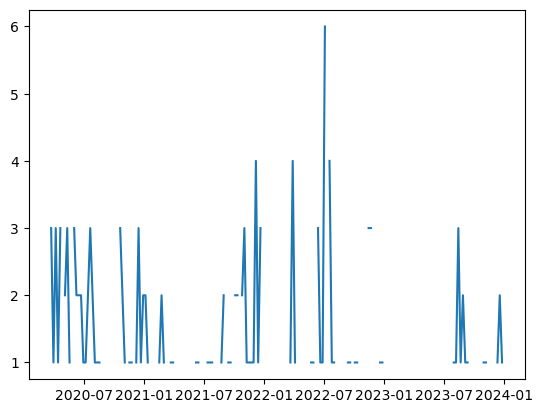

In [27]:
plt.plot(df_final['week'], df_final['zika'])

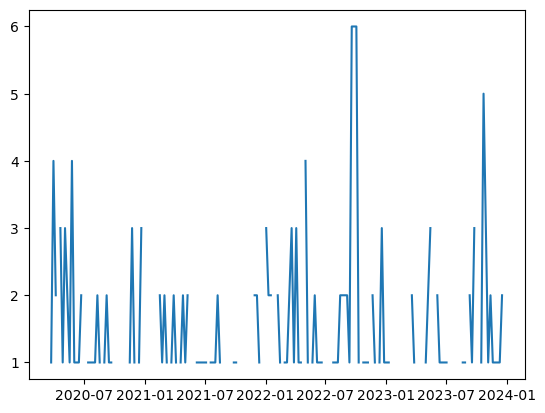

In [28]:
plt.plot(df_final['week'], df_final['chik'])

The null values are almost 100% sure to be 0 / there are few contagions because is eradicated, so there are no reported cases for those dates

In [30]:
df_final['chik'] = df_final['chik'].fillna(0)
df_final['zika'] = df_final['zika'].fillna(0)

In [32]:
df_final.to_csv('gold/epidemics.csv', index = False)